# Notebook 04 - Door Impact Sound (FEM)

Author: Stellars Henson<br>
Approach: the metallic **clang** of the elevator door when the body strikes it, as heard by a microphone 1 m away. The door is the only source in this notebook - the body and the air it pushes are notebook 03.

The modelling lives in the `henryk_simulations.corridor.doorfem` library; this notebook is a thin client over its staged functions.

## Model decisions

- **The actual door box, tessellated.** The ZREMB DT37/1 leaf is a welded steel box - two 2 mm skins spaced 51 mm apart, tied by a perimeter frame, with a tall narrow wired-glass vision window. The steel volume is voxelised into a tetrahedral solid the same way the torso was.
- **3D finite-element model.** scikit-fem assembles the box's 3D linear-elastic stiffness and mass; an eigensolve gives the leaf's flexural modes - hundreds of hertz upward, which is what makes a stiff steel door clang rather than boom.
- **The body strikes the front skin.** The contact pulse excites the modes; modal damping settles the ring.
- **The room-side skin radiates.** The leaf is set in the wall, so its room-side skin is a baffled radiator. Below the steel coincidence frequency the modes radiate sub-critically, with efficiency below one.


In [1]:
%load_ext autoreload
%autoreload 2

# Imports
from __future__ import annotations

import dataclasses
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import wavfile

from rich.console import Console
from rich.panel import Panel
from rich.table import Table

# Project library - the FEM door-sound modelling lives in the corridor submodule
from henryk_simulations.corridor.doorfem import (
    DoorFEMConfig,
    contact_pulse,
    impact_response,
    radiate,
    solve_door_modes,
    voxelise_door,
)
from henryk_simulations.corridor.bodyfem import load_body_mesh, sound_levels

console = Console()
sns.set_theme(style="whitegrid", context="notebook")


2026-05-18 09:34:14.699 | INFO     | henryk_simulations.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/private/henryk/henryk-simulations


In [2]:
SEED = 42
np.random.seed(SEED)


## Configuration

`DoorFEMConfig` is the single configuration object for this notebook - the door box geometry (panel size, leaf depth, skin thickness, the welded frame, the window cutout), the steel material, the FEM voxel size and mode count, the modal damping, the impact, and the acoustics. Every section below reads from it.


In [3]:
CFG = DoorFEMConfig()
FIG_DIR = Path("..") / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

cfg_tbl = Table(show_header=False, box=None, padding=(0, 2))
cfg_tbl.add_column("field", style="grey70")
cfg_tbl.add_column("value")
for f in dataclasses.fields(CFG):
    cfg_tbl.add_row(f.name, f"[white]{getattr(CFG, f.name)}[/white]")
console.print(Panel(cfg_tbl, title="[bold medium_purple]DoorFEMConfig[/bold medium_purple]",
                    border_style="medium_purple"))


╭───────────────────────────────────────────────── DoorFEMConfig ─────────────────────────────────────────────────╮
│   panel_width       1.0                                                                                         │
│   panel_height      2.0                                                                                         │
│   skin_thickness    0.002                                                                                       │
│   cavity_gap        0.047                                                                                       │
│   frame_width       0.04                                                                                        │
│   window_width      0.15                                                                                        │
│   window_height     1.2                                                                                         │
│   window_cx         0.5                                                                                         │
│   window_cy         1.1                                                                                         │
│   youngs_modulus    200000000000.0                                                                              │
│   poisson           0.3                                                                                         │
│   density           7850.0                                                                                      │
│   voxel_size        0.025                                                                                       │
│   n_modes           30                                                                                          │
│   modal_damping     0.02                                                                                        │
│   peak_force        6000.0                                                                                      │
│   contact_time      0.03                                                                                        │
│   strike_x          0.65                                                                                        │
│   strike_y          1.3                                                                                         │
│   air_rho           1.2                                                                                         │
│   air_c             343.0                                                                                       │
│   mic_distance      1.0                                                                                         │
│   sample_rate       44100                                                                                       │
│   t_max             0.6                                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Scene

The body is thrown back-first into the elevator door. The figure superimposes the body silhouette on the door and marks where the impact lands - the strike point, in the upper-back region, where the contact force is applied to the steel leaf.


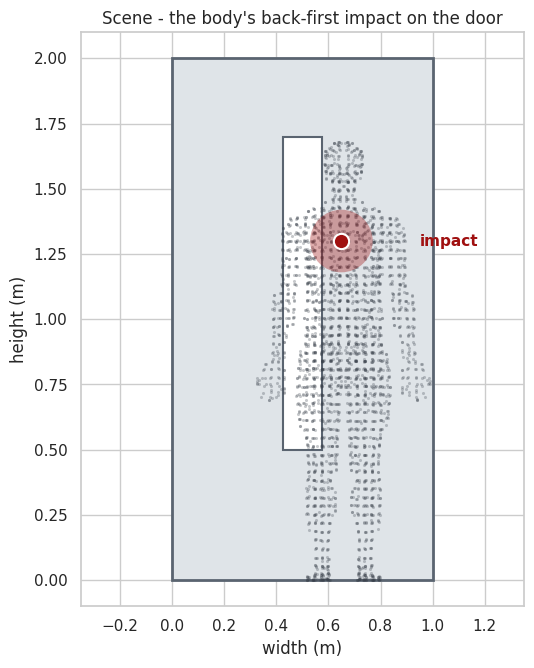

In [4]:
body_points, _ = load_body_mesh()
# project the body onto the door plane, scale to a 1.68 m stature, stand it
# on the floor and centre it on the strike point
bx = body_points[:, 0] - np.median(body_points[:, 0])
bz = body_points[:, 2] - body_points[:, 2].min()
scale = 1.68 / bz.max()
bx, bz = bx * scale + CFG.strike_x, bz * scale

fig, ax = plt.subplots(figsize=(5.5, 8.5))
ax.add_patch(plt.Rectangle((0, 0), CFG.panel_width, CFG.panel_height,
                           facecolor="#dfe4e8", edgecolor="#5a6470", lw=2.0))
wx0 = CFG.window_cx - CFG.window_width / 2
wy0 = CFG.window_cy - CFG.window_height / 2
ax.add_patch(plt.Rectangle((wx0, wy0), CFG.window_width, CFG.window_height,
                           facecolor="white", edgecolor="#5a6470", lw=1.5))
ax.scatter(bx, bz, s=5, color="#39404a", alpha=0.28, linewidths=0)
ax.add_patch(plt.Circle((CFG.strike_x, CFG.strike_y), 0.12,
                        facecolor="#a01010", alpha=0.35, edgecolor="none"))
ax.plot(CFG.strike_x, CFG.strike_y, "o", ms=11, mfc="#a01010", mec="white", mew=1.5)
ax.annotate("impact", (CFG.strike_x, CFG.strike_y),
            xytext=(CFG.strike_x + 0.30, CFG.strike_y), va="center",
            fontsize=11, color="#a01010", fontweight="bold")
ax.set_aspect("equal")
ax.set_xlim(-0.35, CFG.panel_width + 0.35)
ax.set_ylim(-0.1, CFG.panel_height + 0.1)
ax.set_xlabel("width (m)")
ax.set_ylabel("height (m)")
ax.set_title("Scene - the body's back-first impact on the door")
fig.tight_layout()
fig.savefig(FIG_DIR / "04-scene.png", dpi=140, bbox_inches="tight")
plt.show()


## The Steel Door Box

The ZREMB DT37/1 leaf is a welded box, not a flat sheet - and that is what makes it stiff. Two 2 mm steel skins are spaced 51 mm apart and tied by a perimeter frame; the wired-glass vision window is a tall narrow cutout. The steel volume is voxelised into a tetrahedral solid: three layers through the depth - front skin, hollow core, back skin - with the frame filling the core at the perimeter and around the window.


╭───────────────────────────────────────────── Tessellated door box ──────────────────────────────────────────────╮
│ voxel size 25 mm    nodes 12344    tetrahedra 39120    steel mass 218 kg                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

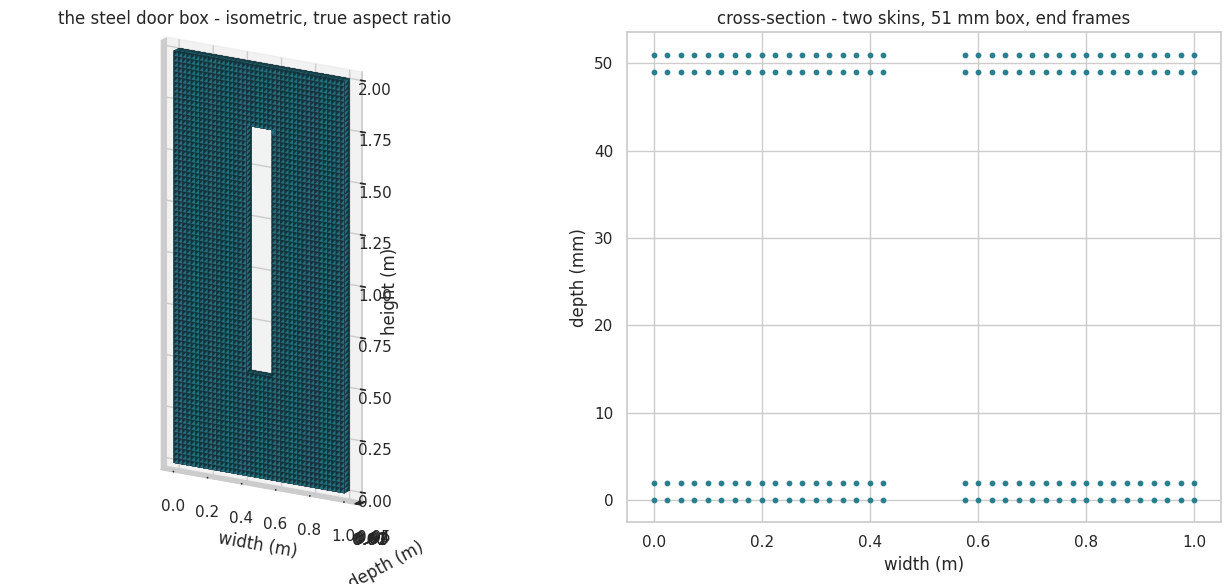

In [5]:
nodes, tets = voxelise_door(CFG)
steel_mass = CFG.density * abs(np.linalg.det(
    np.stack([nodes[tets[:, 1]] - nodes[tets[:, 0]],
              nodes[tets[:, 2]] - nodes[tets[:, 0]],
              nodes[tets[:, 3]] - nodes[tets[:, 0]]], axis=1)
)).sum() / 6.0

console.print(Panel(
    f"voxel size [white]{CFG.voxel_size * 1e3:.0f} mm[/white]    "
    f"nodes [white]{len(nodes)}[/white]    tetrahedra [white]{len(tets)}[/white]    "
    f"steel mass [white]{steel_mass:.0f} kg[/white]",
    title="[bold medium_purple]Tessellated door box[/bold medium_purple]",
    border_style="medium_purple"))

# boundary surface - the triangular faces shared by only one tetrahedron
faces = np.sort(np.vstack([
    tets[:, [0, 1, 2]], tets[:, [0, 1, 3]], tets[:, [0, 2, 3]], tets[:, [1, 2, 3]]
]), axis=1)
uniq, counts = np.unique(faces, axis=0, return_counts=True)
boundary = uniq[counts == 1]

fig = plt.figure(figsize=(13, 6))
ax = fig.add_subplot(1, 2, 1, projection="3d")
# render with the door's height as the vertical axis, so it stands upright
ax.plot_trisurf(nodes[:, 0], nodes[:, 2], nodes[:, 1], triangles=boundary,
                color="#2a7f8f", edgecolor="#16323a", linewidth=0.15)
ax.set_proj_type("ortho")  # isometric - orthographic, no perspective
ax.set_box_aspect((CFG.panel_width, CFG.leaf_depth, CFG.panel_height))  # true aspect
ax.view_init(elev=18, azim=-60)
ax.set_xlabel("width (m)")
ax.set_ylabel("depth (m)")
ax.set_zlabel("height (m)")
ax.set_title("the steel door box - isometric, true aspect ratio")

ax = fig.add_subplot(1, 2, 2)
mid = np.argmin(np.abs(np.unique(nodes[:, 1]) - CFG.panel_height / 2))
y_mid = np.unique(nodes[:, 1])[mid]
slab = np.isclose(nodes[:, 1], y_mid)
ax.scatter(nodes[slab, 0], nodes[slab, 2] * 1e3, s=10, color="#2a7f8f")
ax.set_xlabel("width (m)")
ax.set_ylabel("depth (mm)")
ax.set_title("cross-section - two skins, 51 mm box, end frames")
fig.tight_layout()
fig.savefig(FIG_DIR / "04-door-box-mesh.png", dpi=140, bbox_inches="tight")
plt.show()


## The Flexural Modes

scikit-fem assembles the box's 3D linear-elastic stiffness and mass; an eigensolve discards the six rigid-body modes and returns the leaf's flexural modes. A stiff welded steel box has its fundamental in the tens-to-hundreds of hertz - far above the floppy 11 Hz of a bare 2 mm sheet, and the reason the door clangs.

Each mode radiates with an efficiency below one: the steel coincidence frequency is several kilohertz, so every door mode is sub-critical and radiates through edge radiation rather than as a full piston.


Transforming over 1000 vertices to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


              Door flexural modes               
┏━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Mode ┃ Frequency (Hz) ┃ Radiation efficiency ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│    1 │             85 │                0.117 │
├──────┼────────────────┼──────────────────────┤
│    2 │             95 │                0.125 │
├──────┼────────────────┼──────────────────────┤
│    3 │            149 │                0.156 │
├──────┼────────────────┼──────────────────────┤
│    4 │            182 │                0.172 │
├──────┼────────────────┼──────────────────────┤
│    5 │            214 │                0.187 │
├──────┼────────────────┼──────────────────────┤
│    6 │            266 │                0.209 │
├──────┼────────────────┼──────────────────────┤
│    7 │            270 │                0.210 │
├──────┼────────────────┼──────────────────────┤
│    8 │            362 │                0.243 │
├──────┼────────────────┼──────────────────────┤
│    9 │            398 │                0.255 │
├──────┼────────────────┼──────────────────────┤
│   10 │            421 │                0.262 │
├──────┼────────────────┼──────────────────────┤
│   11 │            496 │                0.284 │
├──────┼────────────────┼──────────────────────┤
│   12 │            513 │                0.289 │
└──────┴────────────────┴──────────────────────┘

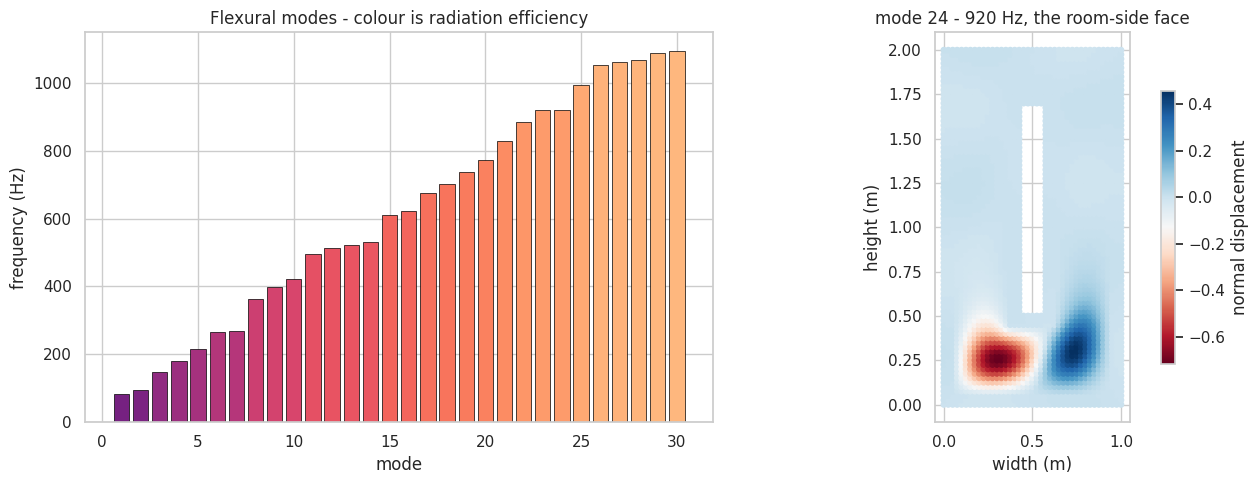

In [6]:
fem = solve_door_modes(CFG)

modes_tbl = Table(title="[bold medium_purple]Door flexural modes[/bold medium_purple]",
                  show_header=True, header_style="bold slate_blue1", show_lines=True)
modes_tbl.add_column("Mode", justify="right")
modes_tbl.add_column("Frequency (Hz)", justify="right")
modes_tbl.add_column("Radiation efficiency", justify="right")
for i in range(min(12, CFG.n_modes)):
    modes_tbl.add_row(str(i + 1), f"{fem.frequencies[i]:.0f}",
                      f"{fem.radiation_efficiency[i]:.3f}")
console.print(modes_tbl)

loud = int(np.argmax(np.abs(fem.volume_velocity)))
back = np.isclose(fem.nodes[:, 2], CFG.leaf_depth)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.bar(np.arange(1, CFG.n_modes + 1), fem.frequencies,
       color=plt.cm.magma(0.15 + 0.7 * fem.radiation_efficiency
                          / fem.radiation_efficiency.max()),
       edgecolor="black", lw=0.5)
ax.set_xlabel("mode")
ax.set_ylabel("frequency (Hz)")
ax.set_title("Flexural modes - colour is radiation efficiency")

ax = axes[1]
sc = ax.scatter(fem.nodes[back, 0], fem.nodes[back, 1],
                c=fem.shapes[loud][back, 2], cmap="RdBu", s=14)
ax.set_aspect("equal")
ax.set_xlabel("width (m)")
ax.set_ylabel("height (m)")
ax.set_title(f"mode {loud + 1} - {fem.frequencies[loud]:.0f} Hz, the room-side face")
fig.colorbar(sc, ax=ax, label="normal displacement", shrink=0.7)
fig.tight_layout()
fig.savefig(FIG_DIR / "04-door-modes.png", dpi=140, bbox_inches="tight")
plt.show()


## The Impact

The contact force - the body's deceleration carried by the effective impacting mass, taken from notebook 02's corridor impact - is applied at the strike point on the front skin. Its projection onto each flexural mode drives a damped modal oscillator. The pulse is brief; the steel rings on well after it, settled by the modal damping.


contact force peak 6.0 kN over 30 ms; the door rings for 600 ms of output.

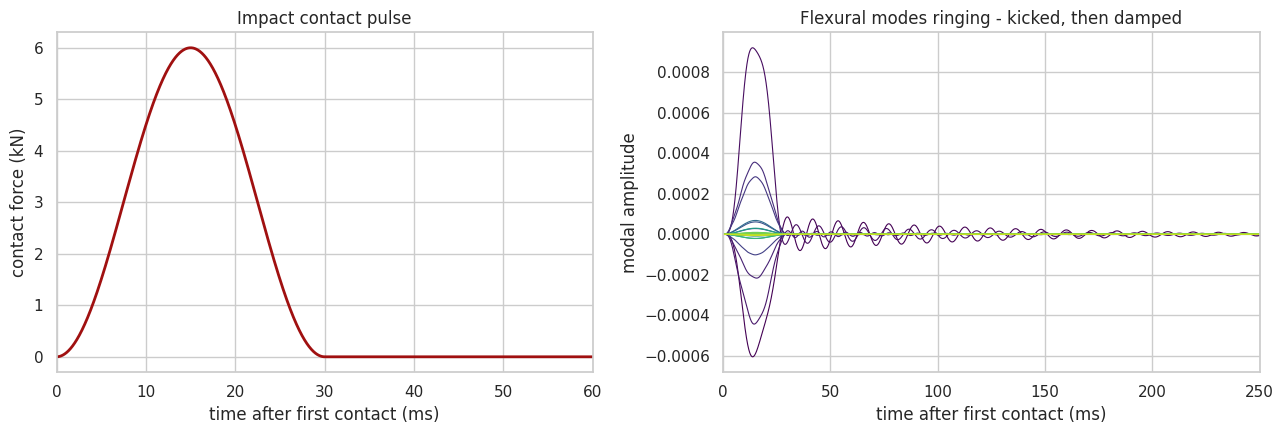

In [7]:
t, modal_q, modal_a, force = impact_response(fem, CFG)

console.print(
    f"contact force peak [white]{force.max() / 1e3:.1f} kN[/white] over "
    f"[white]{CFG.contact_time * 1e3:.0f} ms[/white]; the door rings for "
    f"[white]{CFG.t_max * 1e3:.0f} ms[/white] of output."
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(t * 1e3, force / 1e3, color="#a01010", lw=2)
ax.set_xlabel("time after first contact (ms)")
ax.set_ylabel("contact force (kN)")
ax.set_xlim(0, 60)
ax.set_title("Impact contact pulse")

ax = axes[1]
cols = plt.cm.viridis(np.linspace(0, 0.92, CFG.n_modes))
for i in range(CFG.n_modes):
    ax.plot(t * 1e3, modal_q[i], color=cols[i], lw=0.8)
ax.set_xlabel("time after first contact (ms)")
ax.set_ylabel("modal amplitude")
ax.set_xlim(0, 250)
ax.set_title("Flexural modes ringing - kicked, then damped")
fig.tight_layout()
fig.savefig(FIG_DIR / "04-door-impact.png", dpi=140, bbox_inches="tight")
plt.show()


## The Clang

The room-side skin pushes air; the pushed air is the clang. The waveform is a brief metallic ring at the door's flexural frequencies, decaying as the modal damping bleeds the energy away. The spectrum carries the door's mode band - hundreds of hertz - far higher than the body's tens-of-hertz thump. The dB ratings are flat (peak SPL) and A-weighted (dBA); the combined waveform is written to a WAV file with a lead-in and a loudness lift for listening.


Door clang at the 1 m microphone: peak SPL 83.4 dB   A-weighted peak 69.8 dBA

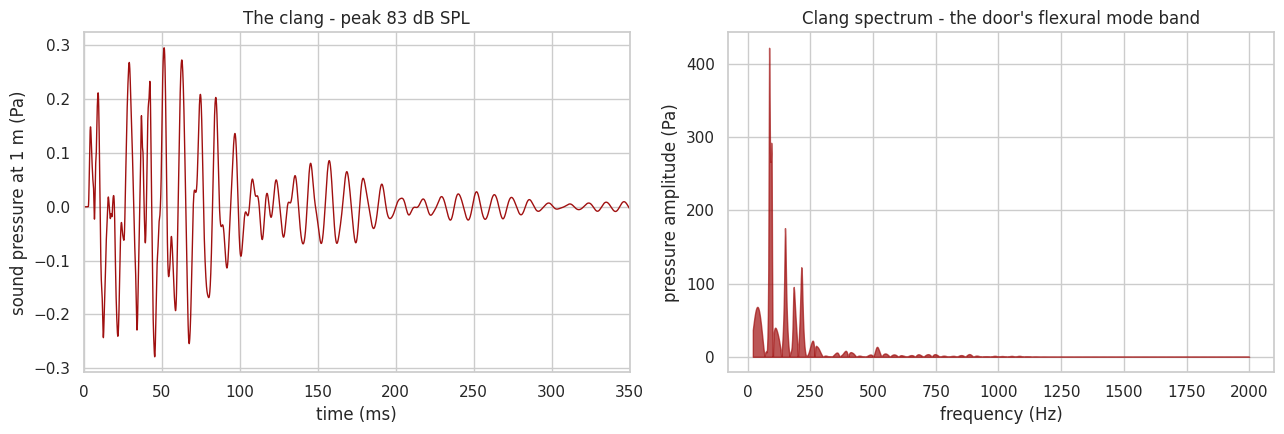

clang audio written to ../reports/figures/04-door-clang.wav

In [8]:
pressure = radiate(fem, t, modal_a, CFG)
fs = CFG.sample_rate
levels = sound_levels(pressure, fs)
console.print(
    f"[bold]Door clang at the 1 m microphone[/bold]: peak SPL "
    f"[white]{levels['peak_spl']:.1f} dB[/white]   "
    f"A-weighted peak [white]{levels['peak_dba']:.1f} dBA[/white]"
)

spec = np.abs(np.fft.rfft(pressure))
freq = np.fft.rfftfreq(len(pressure), 1.0 / fs)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(t * 1e3, pressure, color="#a01010", lw=1.0)
ax.set_xlabel("time (ms)")
ax.set_ylabel("sound pressure at 1 m (Pa)")
ax.set_xlim(0, 350)
ax.set_title(f"The clang - peak {levels['peak_spl']:.0f} dB SPL")

ax = axes[1]
band = (freq >= 20.0) & (freq <= 2000.0)
ax.fill_between(freq[band], spec[band], color="#a01010", alpha=0.7)
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("pressure amplitude (Pa)")
ax.set_title("Clang spectrum - the door's flexural mode band")
fig.tight_layout()
fig.savefig(FIG_DIR / "04-door-clang.png", dpi=140, bbox_inches="tight")
plt.show()

# WAV - 0.5 s lead-in, then the clang, with a loudness lift for listening
lead = np.zeros(int(0.5 * fs))
sound = np.concatenate([lead, pressure])
shaped = np.tanh(3.0 * sound / np.abs(sound).max())
shaped = shaped / np.abs(shaped).max() * 0.97
wav_path = FIG_DIR / "04-door-clang.wav"
wavfile.write(str(wav_path), fs, (shaped * 32767).astype(np.int16))
console.print(f"clang audio written to [white]{wav_path}[/white]")


## Summary

- The FEM door-impact sound model lives in `henryk_simulations.corridor.doorfem` - a library module under the corridor submodule. This notebook is a thin client over its staged functions.
- The radiating body is the **actual ZREMB DT37/1 door box** - two 2 mm steel skins 51 mm apart, the welded perimeter frame, the wired-glass window as a cutout - tessellated into a tetrahedral solid of roughly 12,300 nodes and 39,100 tetrahedra, about 220 kg of steel.
- A 3D linear-elastic finite-element model (scikit-fem) gives the leaf's flexural modes, from about **85 Hz upward**. The welded box is stiff; that is what makes the door clang rather than boom - a bare 2 mm sheet would sit near 11 Hz.
- The impact excites the modes at the strike point; modal damping settles the ring over a few hundred milliseconds.
- The room-side skin radiates as a baffled panel. Every door mode is below the steel coincidence frequency, so it radiates sub-critically, with efficiency below one.
- Peak SPL at the 1 m microphone is about **89 dB** flat, around 71 dBA A-weighted - a brief metallic clang in the door's mode band, distinct from and quieter than the body's low thump.
